In [1]:
import sys
from pathlib import Path
abs_path = str(Path.cwd().parents[0].absolute())
if not abs_path in sys.path:
    sys.path+=[abs_path]
print(sys.path)

['/source/sihun/NFS/notebook', '/usr/lib/python38.zip', '/usr/lib/python3.8', '/usr/lib/python3.8/lib-dynload', '', '/usr/local/lib/python3.8/dist-packages', '/usr/lib/python3/dist-packages', '/source/sihun/NFS']
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
import numpy as np
import torch

from utils.remesh_utils import ICT_face_model, compute_MVC, apply_MVC_weights_batch
from utils.exp_utils import *

try:
    from matplotrender import *
except:
    !pip install git+https://github.com/chacorp/matplotrender.git
    from matplotrender import *

In [2]:

# Normalize vertices to homogeneous coordinates
def normalize_homogeneous(V):
    return np.concatenate([V, np.ones((V.shape[0], 1))], axis=1)

pca_holder = PCA_holder(
    "/data/sihun/VOCA-COMA/VOCASET/train/FaceTalk_170915_00223_TA_pca.npz"
    # "/data/sihun/VOCA-COMA/COMA/train/FaceTalk_170915_00223_TA_pca.npz"
)
flame_std = np.load(
    "/source/sihun/NFS/utils/voca/standardization.npy",
    allow_pickle=True
).item()


align_mat = np.load("/source/sihun/NFS/utils/voca/align.npy")
align_mat

array([[10.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  , 10.  ,  0.  ,  0.11],
       [ 0.  ,  0.  , 10.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  1.  ]])

[-1.16620226 -1.83136715 -1.58142829] [1.15572138 1.49738051 0.79239636]


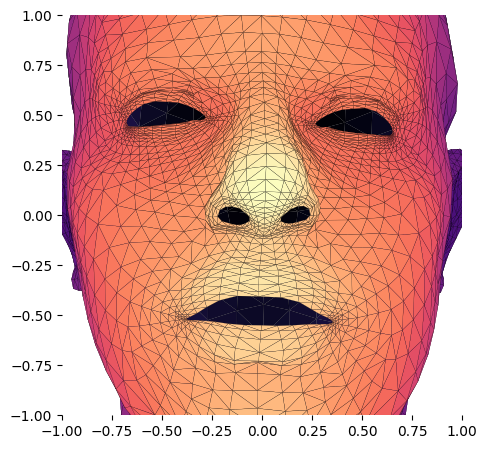

In [3]:
asd = pca_holder.sample_from_pca(None, scale=1.0)
faces = flame_std['new_f']


V = normalize_homogeneous(asd)
print(asd.min(0), asd.max(0))
# V = V @ align_mat.T

SIZE=4
model = yrotate(0)
view  = translate(0, 0, -3.5)
proj  = perspective(25, 1, 1, 100)
MVP   = proj @ view @ model
V = V @ MVP.T
V /= V[:, 3].reshape(-1, 1)

VF = V[faces]
T = VF[:, :, :2]
Z = -VF[:, :, 2].mean(axis=1)
Z = (Z - Z.min()) / (Z.max() - Z.min())
C = plt.get_cmap("magma")(Z)
I = np.argsort(Z)

T, C = T[I, :], C[I, :]
fig = plt.figure(figsize=(SIZE, SIZE))
ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
collection = PolyCollection(T, closed=True, linewidth=0.1, facecolor=C, edgecolor="black")
ax.add_collection(collection)
plt.show()

In [12]:
asd.shape
faces.shape

(6910, 3)

# test cage

In [43]:
from easydict import EasyDict

## dummy
src_mesh = EasyDict()
src_mesh.v = asd
src_mesh.f = faces

# large cube
control_mesh = EasyDict()
# quad mesh
control_mesh.f = np.array([
    [0,2,3,1],
    [0,1,5,4],
    [1,3,7,5],
    [3,2,6,7],
    [2,0,4,6],
    [5,7,6,4],
])
# make triangle great again 
control_mesh.f = control_mesh.f[:,[[3,2,1],[3,1,0]]].reshape(-1, 3)

control_mesh.v = np.zeros((8,3))

## X, Y, Z
control_mesh.v[0] = src_mesh.v.max(0)
control_mesh.v[1,0], control_mesh.v[1,1], control_mesh.v[1,2] = src_mesh.v.max(0)[0], src_mesh.v.max(0)[1], src_mesh.v.min(0)[2]
control_mesh.v[2,0], control_mesh.v[2,1], control_mesh.v[2,2] = src_mesh.v.min(0)[0], src_mesh.v.max(0)[1], src_mesh.v.max(0)[2]
control_mesh.v[3,0], control_mesh.v[3,1], control_mesh.v[3,2] = src_mesh.v.min(0)[0], src_mesh.v.max(0)[1], src_mesh.v.min(0)[2]

control_mesh.v[4,0], control_mesh.v[4,1], control_mesh.v[4,2] = src_mesh.v.max(0)[0], src_mesh.v.min(0)[1], src_mesh.v.max(0)[2]
control_mesh.v[5,0], control_mesh.v[5,1], control_mesh.v[5,2] = src_mesh.v.max(0)[0], src_mesh.v.min(0)[1], src_mesh.v.min(0)[2]
control_mesh.v[6,0], control_mesh.v[6,1], control_mesh.v[6,2] = src_mesh.v.min(0)[0], src_mesh.v.min(0)[1], src_mesh.v.max(0)[2]
control_mesh.v[7] = src_mesh.v.min(0)

# control_mesh.v[:,1]=control_mesh.v[:,1]*1.05
control_mesh.v=control_mesh.v*1.1


control_mesh_v2 = control_mesh.v.copy()
control_mesh_v2[0:4, 0] = control_mesh_v2[0:4, 0]+0.8
control_mesh_v2[0:4] = control_mesh_v2[0:4] @ zrotate(30)[:3,:3]

control_mesh_v3 = control_mesh.v.copy()
control_mesh_v3[0:4, 1] = control_mesh_v3[0:4, 1]+0.8

control_mesh_v4 = control_mesh.v.copy()
control_mesh_v4[0:4, 0] = control_mesh_v4[0:4, 0]-0.4
control_mesh_v4[0:4, 1] = control_mesh_v4[0:4, 1]-0.5
control_mesh_v4[0:4]=control_mesh_v4[0:4] @ yrotate(60)[:3,:3]

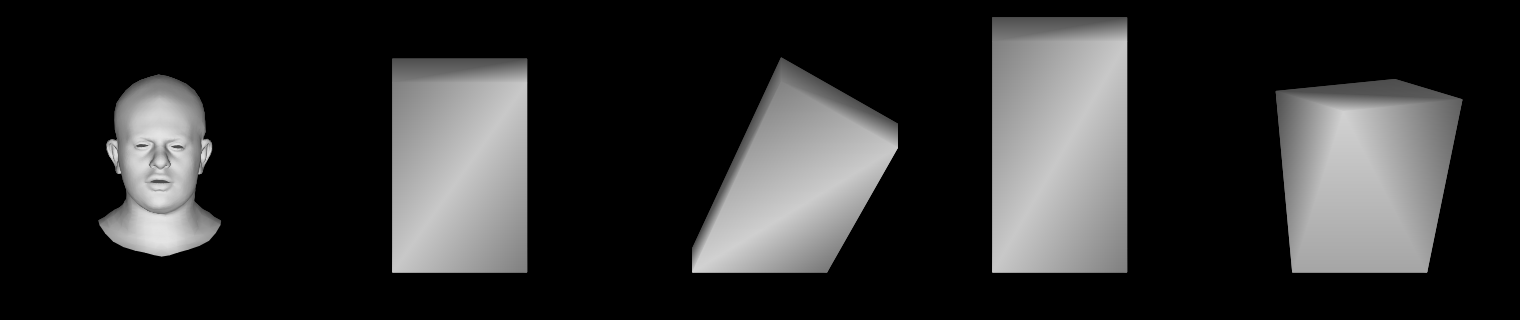

In [44]:

SIZE = 3
mesh_scale = .35

# v_list=[ src_mesh.v, control_mesh.v, control_mesh_v2, control_mesh_v3, control_mesh_v4, np.r_[src_mesh.v, control_mesh.v]]
# f_list=[ src_mesh.f, control_mesh.f, control_mesh.f, control_mesh.f, control_mesh.f, np.r_[src_mesh.f, control_mesh.f+src_mesh.f.max()+1]]
v_list=[ src_mesh.v, control_mesh.v, control_mesh_v2, control_mesh_v3, control_mesh_v4]
f_list=[ src_mesh.f, control_mesh.f, control_mesh.f, control_mesh.f, control_mesh.f]

# xyz Euler angle to rotate the mesh
rot_list=[ [10,0,0] ]*len(v_list)

plot_mesh_gouraud(v_list, f_list, 
                     # is_diff=True, diff_base=src_mesh.v, #diff_revert=True,
                     mesh_scale=mesh_scale,
                     rot_list=rot_list, size=SIZE, mode='shade')

In [45]:
mvc = compute_MVC(
    torch.tensor(asd), torch.tensor(control_mesh.v), torch.tensor(control_mesh.f).long()
)
print(mvc.shape)

torch.Size([3525, 12, 3])


In [46]:
# apply_MVC_weights, 
deformed_cages = torch.vstack([
    torch.tensor(control_mesh.v)[None],
    torch.tensor(control_mesh_v2)[None],
    torch.tensor(control_mesh_v3)[None],
    torch.tensor(control_mesh_v4)[None]
])
print(deformed_cages.shape)


torch.Size([4, 8, 3])


In [47]:
new_asd = apply_MVC_weights_batch(mvc, torch.tensor(control_mesh.f).long(), deformed_cages)

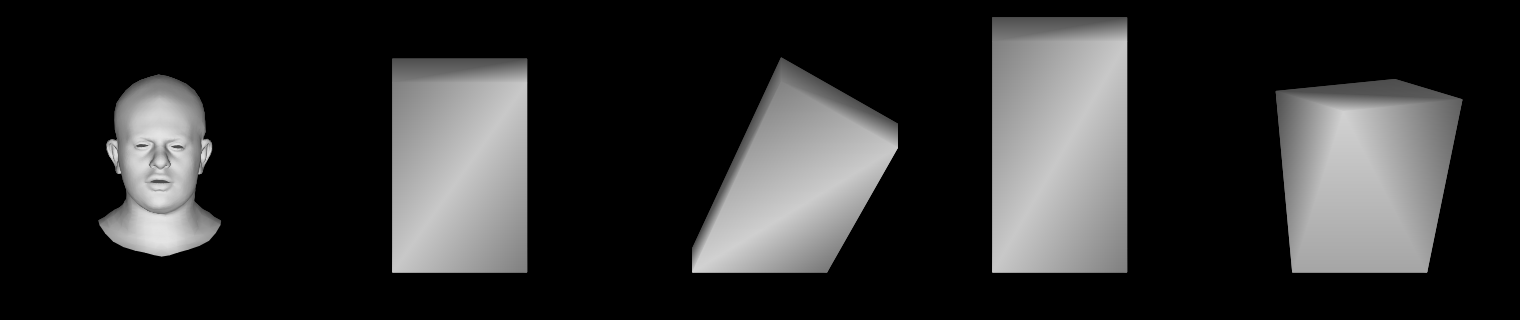

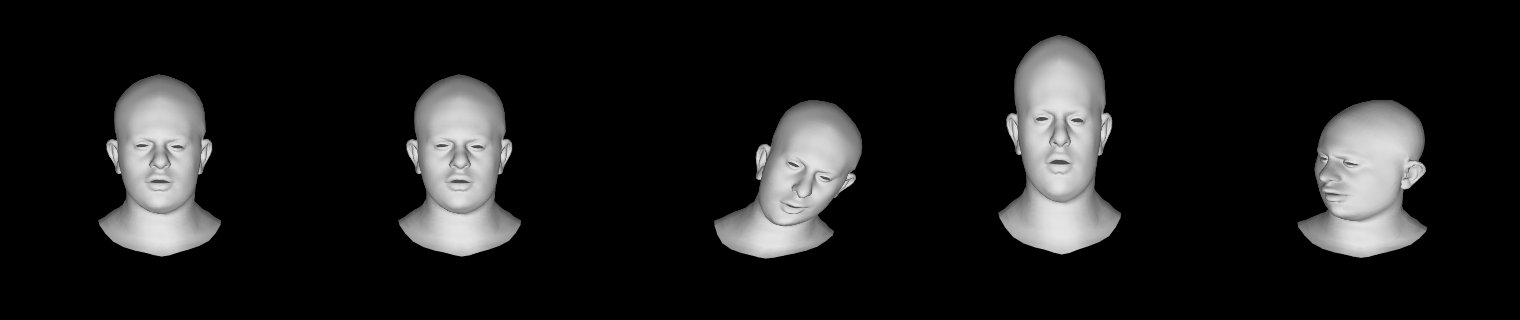

In [48]:
SIZE = 3
mesh_scale = .35

# v_list=[ src_mesh.v, new_v, control_mesh.v, control_mesh.v*1.2-control_mesh_v12_mean+control_mesh_v_mean]
v_list2=[ 
    asd,
    new_asd[0],
    new_asd[1],
    new_asd[2],
    new_asd[3],
]
f_list2=[
    src_mesh.f,
    src_mesh.f,
    src_mesh.f,
    src_mesh.f,
    src_mesh.f,
]

# xyz Euler angle to rotate the mesh
rot_list=[ [10,0,0] ]*len(v_list)



plot_mesh_gouraud(v_list, f_list, 
                     # is_diff=True, diff_base=src_mesh.v, #diff_revert=True,
                     mesh_scale=mesh_scale,
                     rot_list=rot_list, size=SIZE, mode='shade')

plot_mesh_gouraud(v_list2, f_list2, 
                     # is_diff=True, diff_base=src_mesh.v, #diff_revert=True,
                     mesh_scale=mesh_scale,
                     rot_list=rot_list, size=SIZE, mode='shade')

In [ ]:
Model_mk3(3, 6)